## RL

In [2]:
import numpy as np

class ClutchShooterEnv:
    def __init__(self):
        # Define the limits of our state space
        self.max_distance = 5
        self.max_time = 5
        self.reset()
        
    def reset(self):
        # Reset game to start: 5 steps away, 5 seconds on clock
        self.distance = self.max_distance
        self.shot_clock = self.max_time
        return (self.distance, self.shot_clock)
        
    def step(self, action):
        # Action 0: Move Closer
        if action == 0:
            self.distance = max(1, self.distance - 1)
            self.shot_clock -= 1
            
            # Check if shot clock expired
            if self.shot_clock <= 0:
                return (self.distance, self.shot_clock), -2, True  # State, Reward, Done
            else:
                return (self.distance, self.shot_clock), 0, False  # State, Reward, Done
                
        # Action 1: Shoot
        elif action == 1:
            # Determine shot success based on distance
            rand = np.random.rand()
            if self.distance == 5:
                reward = 3 if rand < 0.35 else 0
            elif self.distance >= 3:
                reward = 2 if rand < 0.45 else 0
            else:
                reward = 2 if rand < 0.75 else 0
            
            return (self.distance, self.shot_clock), reward, True

In [3]:
# Dimensions: Distance (0 to 5), Shot Clock (0 to 5), Actions (2 choices)
q_table = np.zeros((6, 6, 2))

In [4]:
# Hyperparameters
alpha = 0.1    # Learning rate
gamma = 0.95   # Discount factor (how much we care about future rewards)
epsilon = 0.2  # Exploration rate (20% of the time, try random moves)
episodes = 10000

env = ClutchShooterEnv()

for episode in range(episodes):
    state = env.reset()
    done = False
    
    while not done:
        dist, clock = state
        
        # 1. Exploration vs Exploitation choice
        if np.random.rand() < epsilon:
            action = np.random.choice([0, 1]) # Explore random move
        else:
            action = np.argmax(q_table[dist, clock]) # Exploit best known move
            
        # 2. Take action, observe new state and reward
        next_state, reward, done = env.step(action)
        next_dist, next_clock = next_state
        
        # 3. Bellman Equation Update
        old_value = q_table[dist, clock, action]
        next_max = np.max(q_table[next_dist, next_clock])
        
        # Update rule
        new_value = old_value + alpha * (reward + gamma * next_max - old_value)
        q_table[dist, clock, action] = new_value
        
        state = next_state

print("Training finished! Your Q-Table is ready.")

Training finished! Your Q-Table is ready.


In [5]:
print(q_table)

[[[ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]]

 [[ 0.          0.        ]
  [-1.62939596 13.01231543]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]]

 [[ 0.          0.        ]
  [ 0.          0.        ]
  [11.48583205  6.93916464]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]]

 [[ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [10.2795581   6.27142787]
  [ 0.          0.        ]
  [ 0.          0.        ]]

 [[ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 9.19205136 18.33633916]
  [ 0.          0.        ]]

 [[ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]
  [17.5275

## Deep RL

In [6]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class Basketball2DEnv(gym.Env):
    def __init__(self):
        super(Basketball2DEnv, self).__init__()
        
        # Actions: 0=Up, 1=Down, 2=Left, 3=Right, 4=Shoot
        self.action_space = spaces.Discrete(5)
        
        # Observation Space: [Agent_X, Agent_Y, Defender_X, Defender_Y, Shot_Clock]
        # High and low bounds define the boundaries of our data
        low = np.array([0, 0, 0, 0, 0], dtype=np.float32)
        high = np.array([9, 9, 9, 9, 24], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        
        # Game constants
        self.basket_pos = np.array([5, 0])
        self.defender_pos = np.array([5, 2])
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # Randomize agent start position along the perimeter (Y positions 5 to 8)
        self.agent_pos = np.array([np.random.randint(1, 9), np.random.randint(5, 8)])
        self.shot_clock = 24
        
        return self._get_obs(), {}
        
    def _get_obs(self):
        return np.array([
            self.agent_pos[0], self.agent_pos[1],
            self.defender_pos[0], self.defender_pos[1],
            self.shot_clock
        ], dtype=np.float32)
        
    def step(self, action):
        self.shot_clock -= 1
        reward = 0
        terminated = False
        truncated = False # Used for time limits, handled by shot_clock here
        
        # Movements
        if action == 0: self.agent_pos[1] = max(0, self.agent_pos[1] - 1)  # Up (towards basket)
        elif action == 1: self.agent_pos[1] = min(9, self.agent_pos[1] + 1) # Down
        elif action == 2: self.agent_pos[0] = max(0, self.agent_pos[0] - 1) # Left
        elif action == 3: self.agent_pos[0] = min(9, self.agent_pos[0] + 1) # Right
        
        # Action 4: Shoot
        elif action == 4:
            terminated = True
            dist_to_basket = np.linalg.norm(self.agent_pos - self.basket_pos)
            dist_to_defender = np.linalg.norm(self.agent_pos - self.defender_pos)
            
            # Shot physics/logic
            if dist_to_defender < 1.5:
                # Heavily contested shot
                reward = -1.0 
            else:
                # Open shot: closer means higher probability of scoring
                success_chance = max(0.2, 1.0 - (dist_to_basket * 0.12))
                if np.random.rand() < success_chance:
                    reward = 2.0  # Bucket!
                else:
                    reward = 0.0  # Missed
                    
        # Check boundary/turnover conditions
        if self.shot_clock <= 0:
            reward = -2.0  # Shot clock violation
            terminated = True
            
        # Collision with defender results in a turnover
        if np.array_equal(self.agent_pos, self.defender_pos):
            reward = -3.0
            terminated = True
            
        return self._get_obs(), reward, terminated, truncated, {}

In [8]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# 1. Instantiate and validate environment structure
env = Basketball2DEnv()
check_env(env) # SB3 utility tool to ensure custom gym setups have no bugs

# 2. Initialize the PPO Agent
# "MlpPolicy" means standard fully connected layers architecture
model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003, n_steps=2048)

print("Starting deep training loop...")
model.learn(total_timesteps=100000)
print("Training complete!")

# Save the trained brain
model.save("ppo_basketball_agent")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/aniketsingh/Music/RL_basic/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Starting deep training loop...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5.66     |
|    ep_rew_mean     | 0.57     |
| time/              |          |
|    fps             | 1563     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4.67        |
|    ep_rew_mean          | 0.42        |
| time/                   |             |
|    fps                  | 1199        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011663474 |
|    clip_fraction        | 0.096       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | -0.0274     |

In [9]:
# Load the trained model
model = PPO.load("ppo_basketball_agent")

# Test loop
obs, info = env.reset()
done = False
step_count = 0

print(f"\n--- Testing Trained Agent ---")
print(f"Starting Position: [{obs[0]}, {obs[1]}]")

while not done:
    # Predict the best action using the neural network
    action, _states = model.predict(obs, deterministic=True)
    
    # Map integers to strings for printing
    action_names = {0: "Move Up", 1: "Move Down", 2: "Move Left", 3: "Move Right", 4: "SHOOT"}
    print(f"Step {step_count}: Agent chose action -> {action_names[int(action)]}")
    
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    step_count += 1
    
    if not done:
        print(f"New Position: [{obs[0]}, {obs[1]}] | Shot Clock: {obs[4]}")
    else:
        print(f"Episode Ended. Final Reward: {reward}")


--- Testing Trained Agent ---
Starting Position: [2.0, 5.0]
Step 0: Agent chose action -> Move Up
New Position: [2.0, 4.0] | Shot Clock: 23.0
Step 1: Agent chose action -> Move Up
New Position: [2.0, 3.0] | Shot Clock: 22.0
Step 2: Agent chose action -> Move Up
New Position: [2.0, 2.0] | Shot Clock: 21.0
Step 3: Agent chose action -> SHOOT
Episode Ended. Final Reward: 2.0


## UI

In [11]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

class Basketball2DEnv(gym.Env):
    def __init__(self):
        super(Basketball2DEnv, self).__init__()
        self.action_space = spaces.Discrete(5)
        
        low = np.array([0, 0, 0, 0, 0], dtype=np.float32)
        high = np.array([9, 9, 9, 9, 24], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        
        self.basket_pos = np.array([5, 0])
        self.defender_pos = np.array([5, 2])
        self.fig, self.ax = None, None # For storing matplotlib objects
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = np.array([np.random.randint(1, 9), np.random.randint(5, 8)])
        self.shot_clock = 24
        # Reset defender back to base position
        self.defender_pos = np.array([5, 2])
        return self._get_obs(), {}
        
    def _get_obs(self):
        return np.array([
            self.agent_pos[0], self.agent_pos[1],
            self.defender_pos[0], self.defender_pos[1],
            self.shot_clock
        ], dtype=np.float32)
        
    def step(self, action):
        self.shot_clock -= 1
        reward = 0
        terminated = False
        truncated = False
        
        if action == 0: self.agent_pos[1] = max(0, self.agent_pos[1] - 1)
        elif action == 1: self.agent_pos[1] = min(9, self.agent_pos[1] + 1)
        elif action == 2: self.agent_pos[0] = max(0, self.agent_pos[0] - 1)
        elif action == 3: self.agent_pos[0] = min(9, self.agent_pos[0] + 1)
        elif action == 4:
            terminated = True
            dist_to_basket = np.linalg.norm(self.agent_pos - self.basket_pos)
            dist_to_defender = np.linalg.norm(self.agent_pos - self.defender_pos)
            
            if dist_to_defender < 1.5:
                reward = -1.0 
            else:
                success_chance = max(0.2, 1.0 - (dist_to_basket * 0.12))
                reward = 2.0 if np.random.rand() < success_chance else 0.0
                    
        if self.shot_clock <= 0:
            reward = -2.0
            terminated = True
            
        if np.array_equal(self.agent_pos, self.defender_pos):
            reward = -3.0
            terminated = True
            
        return self._get_obs(), reward, terminated, truncated, {}

    def render(self, action_taken="None", current_reward=0.0):
        """Draws the 10x10 basketball court grid dynamically inside the notebook."""
        # Setup plot layout on first call
        if self.fig is None or not plt.fignum_exists(self.fig.number):
            self.fig, self.ax = plt.subplots(figsize=(6, 6))
            
        self.ax.clear()
        
        # Draw grid lines to look like a court floor
        self.ax.set_xticks(np.arange(-0.5, 10.5, 1))
        self.ax.set_yticks(np.arange(-0.5, 10.5, 1))
        self.ax.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
        
        # Plot entities with distinct colors and shapes
        # Basket (Orange Hoop)
        self.ax.plot(self.basket_pos[0], self.basket_pos[1], 'o', color='orange', markersize=18, label='Basket')
        # Defender (Red Cross)
        self.ax.plot(self.defender_pos[0], self.defender_pos[1], 'X', color='red', markersize=14, label='Defender')
        # Offense/Agent (Blue Circle)
        self.ax.plot(self.agent_pos[0], self.agent_pos[1], 'o', color='blue', markersize=14, label='Agent (AI)')
        
        # Graph styling
        self.ax.set_xlim(-0.5, 9.5)
        self.ax.set_ylim(9.5, -0.5) # Invert Y axis so 0 is at the top (near the basket)
        self.ax.set_title(f"Shot Clock: {self.shot_clock} | Last Action: {action_taken}\nReward: {current_reward}")
        self.ax.legend(loc='upper right')
        
        # Smooth frame clearing trick for Jupyter
        clear_output(wait=True)
        display(self.fig)
        plt.close(self.fig) # Prevent ghost plots below the cell

In [12]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# 1. Instantiate and validate environment structure
env = Basketball2DEnv()
check_env(env) # SB3 utility tool to ensure custom gym setups have no bugs

# 2. Initialize the PPO Agent
# "MlpPolicy" means standard fully connected layers architecture
model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003, n_steps=2048)

print("Starting deep training loop...")
model.learn(total_timesteps=100000)
print("Training complete!")

# Save the trained brain
model.save("ppo_basketball_agent_UI")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting deep training loop...


/home/aniketsingh/Music/RL_basic/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4.63     |
|    ep_rew_mean     | 0.54     |
| time/              |          |
|    fps             | 1657     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4.46        |
|    ep_rew_mean          | 0.55        |
| time/                   |             |
|    fps                  | 1428        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013820454 |
|    clip_fraction        | 0.13        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | 0.023       |
|    learning_rate        | 0.

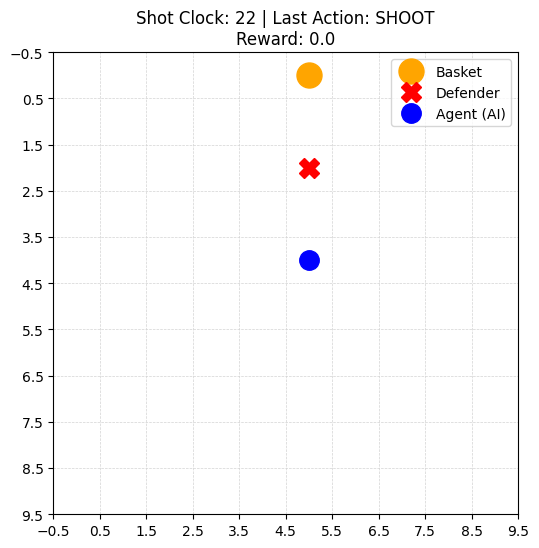

Game Simulation Finished!


In [20]:
import time
from stable_baselines3 import PPO

# Load your model and reset environment
model = PPO.load("ppo_basketball_agent_UI")
env = Basketball2DEnv()
obs, info = env.reset()
done = False

action_names = {0: "Move Up", 1: "Move Down", 2: "Move Left", 3: "Move Right", 4: "SHOOT"}
reward = 0.0

# Render the starting frame
env.render(action_taken="Game Start", current_reward=reward)
time.sleep(1.0)

while not done:
    # Predict the action
    action, _states = model.predict(obs, deterministic=True)
    action_str = action_names[int(action)]
    
    # Process environment
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    
    # Render updated state
    env.render(action_taken=action_str, current_reward=reward)
    time.sleep(0.6) # Controls how fast the animation runs

print("Game Simulation Finished!")

## Moving Defender

In [21]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

class Basketball2DEnv(gym.Env):
    def __init__(self):
        super(Basketball2DEnv, self).__init__()
        self.action_space = spaces.Discrete(5)
        
        low = np.array([0, 0, 0, 0, 0], dtype=np.float32)
        high = np.array([9, 9, 9, 9, 24], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        
        self.basket_pos = np.array([5, 0])
        self.defender_pos = np.array([5, 2])
        self.fig, self.ax = None, None # For storing matplotlib objects
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = np.array([np.random.randint(1, 9), np.random.randint(5, 8)])
        self.shot_clock = 24
        # Reset defender back to base position
        self.defender_pos = np.array([5, 2])
        return self._get_obs(), {}
        
    def _get_obs(self):
        return np.array([
            self.agent_pos[0], self.agent_pos[1],
            self.defender_pos[0], self.defender_pos[1],
            self.shot_clock
        ], dtype=np.float32)
        
    def step(self, action):
        self.shot_clock -= 1
        reward = 0
        terminated = False
        truncated = False
        
        # 1. Process Agent Movement Choices
        if action == 0: self.agent_pos[1] = max(0, self.agent_pos[1] - 1)
        elif action == 1: self.agent_pos[1] = min(9, self.agent_pos[1] + 1)
        elif action == 2: self.agent_pos[0] = max(0, self.agent_pos[0] - 1)
        elif action == 3: self.agent_pos[0] = min(9, self.agent_pos[0] + 1)
        
        # 2. Dynamic Defender AI Logic (Tracks the Agent)
        # Only moves if the agent didn't choose to shoot this turn
        if action != 4:
            if self.defender_pos[0] < self.agent_pos[0]:
                self.defender_pos[0] += 1
            elif self.defender_pos[0] > self.agent_pos[0]:
                self.defender_pos[0] -= 1
                
            if self.defender_pos[1] < self.agent_pos[1]:
                self.defender_pos[1] += 1
            elif self.defender_pos[1] > self.agent_pos[1]:
                self.defender_pos[1] -= 1

        # 3. Process Shoot Action / Outcome Scoring
        if action == 4:
            terminated = True
            dist_to_basket = np.linalg.norm(self.agent_pos - self.basket_pos)
            dist_to_defender = np.linalg.norm(self.agent_pos - self.defender_pos)
            
            if dist_to_defender < 1.5:
                reward = -1.0  # Blocked / Contested
            else:
                success_chance = max(0.2, 1.0 - (dist_to_basket * 0.12))
                reward = 2.0 if np.random.rand() < success_chance else 0.0
                    
        # 4. Check Boundary / Turnover Conditions
        if self.shot_clock <= 0:
            reward = -2.0
            terminated = True
            
        # Collision check (Did the defender tackle the agent?)
        if np.array_equal(self.agent_pos, self.defender_pos):
            reward = -3.0
            terminated = True
            
        return self._get_obs(), reward, terminated, truncated, {}


    def render(self, action_taken="None", current_reward=0.0):
        """Draws the 10x10 basketball court grid dynamically inside the notebook."""
        # Setup plot layout on first call
        if self.fig is None or not plt.fignum_exists(self.fig.number):
            self.fig, self.ax = plt.subplots(figsize=(6, 6))
            
        self.ax.clear()
        
        # Draw grid lines to look like a court floor
        self.ax.set_xticks(np.arange(-0.5, 10.5, 1))
        self.ax.set_yticks(np.arange(-0.5, 10.5, 1))
        self.ax.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
        
        # Plot entities with distinct colors and shapes
        # Basket (Orange Hoop)
        self.ax.plot(self.basket_pos[0], self.basket_pos[1], 'o', color='orange', markersize=18, label='Basket')
        # Defender (Red Cross)
        self.ax.plot(self.defender_pos[0], self.defender_pos[1], 'X', color='red', markersize=14, label='Defender')
        # Offense/Agent (Blue Circle)
        self.ax.plot(self.agent_pos[0], self.agent_pos[1], 'o', color='blue', markersize=14, label='Agent (AI)')
        
        # Graph styling
        self.ax.set_xlim(-0.5, 9.5)
        self.ax.set_ylim(9.5, -0.5) # Invert Y axis so 0 is at the top (near the basket)
        self.ax.set_title(f"Shot Clock: {self.shot_clock} | Last Action: {action_taken}\nReward: {current_reward}")
        self.ax.legend(loc='upper right')
        
        # Smooth frame clearing trick for Jupyter
        clear_output(wait=True)
        display(self.fig)
        plt.close(self.fig) # Prevent ghost plots below the cell

In [22]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# 1. Instantiate and validate environment structure
env = Basketball2DEnv()
check_env(env) # SB3 utility tool to ensure custom gym setups have no bugs

# 2. Initialize the PPO Agent
# "MlpPolicy" means standard fully connected layers architecture
model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003, n_steps=2048)

print("Starting deep training loop...")
model.learn(total_timesteps=100000)
print("Training complete!")

# Save the trained brain
model.save("ppo_basketball_agent_moving_defender_UI")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting deep training loop...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.02     |
|    ep_rew_mean     | -0.88    |
| time/              |          |
|    fps             | 1834     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 2.75        |
|    ep_rew_mean          | -0.28       |
| time/                   |             |
|    fps                  | 1410        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.033960573 |
|    clip_fraction        | 0.454       |
|    clip_range           | 0.

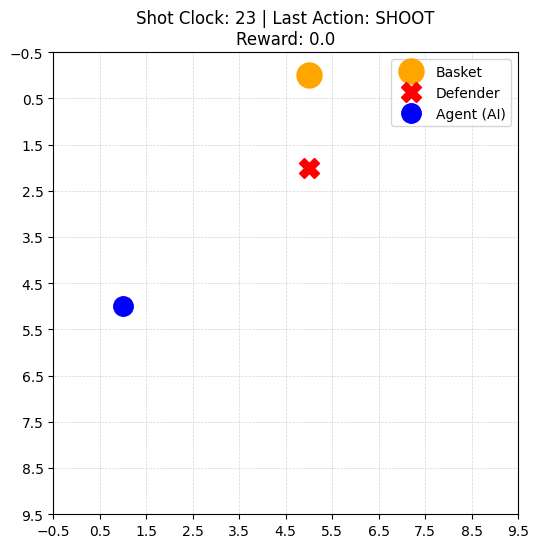

Game Simulation Finished!


In [37]:
import time
from stable_baselines3 import PPO

# Load your model and reset environment
model = PPO.load("ppo_basketball_agent_moving_defender_UI")
env = Basketball2DEnv()
obs, info = env.reset()
done = False

action_names = {0: "Move Up", 1: "Move Down", 2: "Move Left", 3: "Move Right", 4: "SHOOT"}
reward = 0.0

# Render the starting frame
env.render(action_taken="Game Start", current_reward=reward)
time.sleep(1.0)

while not done:
    # Predict the action
    action, _states = model.predict(obs, deterministic=True)
    action_str = action_names[int(action)]
    
    # Process environment
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    
    # Render updated state
    env.render(action_taken=action_str, current_reward=reward)
    time.sleep(0.6) # Controls how fast the animation runs

print("Game Simulation Finished!")

In [40]:
# Load the trained model
model = PPO.load("ppo_basketball_agent_moving_defender_UI")

# Test loop
obs, info = env.reset()
done = False
step_count = 0

print(f"\n--- Testing Trained Agent ---")
print(f"Starting Position: [{obs[0]}, {obs[1]}]")

while not done:
    # Predict the best action using the neural network
    action, _states = model.predict(obs, deterministic=True)
    
    # Map integers to strings for printing
    action_names = {0: "Move Up", 1: "Move Down", 2: "Move Left", 3: "Move Right", 4: "SHOOT"}
    print(f"Step {step_count}: Agent chose action -> {action_names[int(action)]}")
    
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    step_count += 1
    
    if not done:
        print(f"New Position: [{obs[0]}, {obs[1]}] | Shot Clock: {obs[4]}")
    else:
        print(f"Episode Ended. Final Reward: {reward}")


--- Testing Trained Agent ---
Starting Position: [2.0, 6.0]
Step 0: Agent chose action -> SHOOT
Episode Ended. Final Reward: 0.0


# notes 

When we made the defender hunt the agent down, we accidentally created a massive risk for moving forward. Let’s look at the math from the agent’s perspective:

    The Cost of Dribbling: If it tries to move closer, the defender steps directly into its path. If they collide, the agent gets a massive punishment of -3.0.

    The Lazy Shot Alternative: If it shoots immediately from its starting position (say, 6 or 7 units away), its chance of scoring is low, but the reward for a miss is 0.0. If it hits, it gets +2.0.

    The Expected Value: Because a miss (0.0) is vastly superior to getting trapped or tackled by a moving defender (-3.0), the neural network calculated that driving inside is statistically a terrible gamble. It prefers to take the low-percentage shot immediately to stay safe.

In RL theory, this is known as a suboptimal local minimum. The agent learned a "cowardly" policy because our reward signal made it too afraid of the defender.

## How to Fix It: Reward Engineering

To make the agent play like a real basketball player who breaks ankles and drives to the rim, we have to adjust its incentives. We need to do two things:

    Reward progress: Give it a tiny positive reward for moving closer to the basket without getting caught.

    Normalize the penalties: Make a missed shot slightly disappointing, so it doesn't just treat chucking as a zero-risk escape hatch.

In [42]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

class Basketball2DEnv(gym.Env):
    def __init__(self):
        super(Basketball2DEnv, self).__init__()
        self.action_space = spaces.Discrete(5)
        
        low = np.array([0, 0, 0, 0, 0], dtype=np.float32)
        high = np.array([9, 9, 9, 9, 24], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        
        self.basket_pos = np.array([5, 0])
        self.defender_pos = np.array([5, 2])
        self.fig, self.ax = None, None # For storing matplotlib objects
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = np.array([np.random.randint(1, 9), np.random.randint(5, 8)])
        self.shot_clock = 24
        # Reset defender back to base position
        self.defender_pos = np.array([5, 2])
        return self._get_obs(), {}
        
    def _get_obs(self):
        return np.array([
            self.agent_pos[0], self.agent_pos[1],
            self.defender_pos[0], self.defender_pos[1],
            self.shot_clock
        ], dtype=np.float32)
        
    def step(self, action):
        self.shot_clock -= 1
        reward = 0
        terminated = False
        truncated = False
        
        # Track old distance to basket BEFORE moving
        old_dist = np.linalg.norm(self.agent_pos - self.basket_pos)
        
        # 1. Process Agent Movement
        if action == 0: self.agent_pos[1] = max(0, self.agent_pos[1] - 1)
        elif action == 1: self.agent_pos[1] = min(9, self.agent_pos[1] + 1)
        elif action == 2: self.agent_pos[0] = max(0, self.agent_pos[0] - 1)
        elif action == 3: self.agent_pos[0] = min(9, self.agent_pos[0] + 1)
        
        # Calculate new distance to basket AFTER moving
        new_dist = np.linalg.norm(self.agent_pos - self.basket_pos)
        
        # [NEW] Progress Reward: If it got closer to the hoop by moving, give a small bonus!
        if action in [0, 1, 2, 3] and new_dist < old_dist:
            reward += 0.1  # Encourages attacking the paint
            
        # 2. Dynamic Defender AI Logic (Tracks the Agent)
        if action != 4:
            if self.defender_pos[0] < self.agent_pos[0]: self.defender_pos[0] += 1
            elif self.defender_pos[0] > self.agent_pos[0]: self.defender_pos[0] -= 1
                
            if self.defender_pos[1] < self.agent_pos[1]: self.defender_pos[1] += 1
            elif self.defender_pos[1] > self.agent_pos[1]: self.defender_pos[1] -= 1

        # 3. Process Shoot Action
        if action == 4:
            terminated = True
            dist_to_basket = np.linalg.norm(self.agent_pos - self.basket_pos)
            dist_to_defender = np.linalg.norm(self.agent_pos - self.defender_pos)
            
            if dist_to_defender < 1.5:
                reward = -1.5  # Blocked
            else:
                success_chance = max(0.1, 1.0 - (dist_to_basket * 0.12))
                if np.random.rand() < success_chance:
                    reward = 3.0  # Increased reward for a basket
                else:
                    reward = -0.2  # [NEW] Slight penalty for missing, discourages full-court chucking
                    
        # 4. Check Turnovers
        if self.shot_clock <= 0:
            reward = -1.0
            terminated = True
            
        if np.array_equal(self.agent_pos, self.defender_pos):
            reward = -2.0  # Reduced penalty slightly so it isn't completely paralyzed by fear
            terminated = True
            
        return self._get_obs(), reward, terminated, truncated, {}

    def render(self, action_taken="None", current_reward=0.0):
        """Draws the 10x10 basketball court grid dynamically inside the notebook."""
        # Setup plot layout on first call
        if self.fig is None or not plt.fignum_exists(self.fig.number):
            self.fig, self.ax = plt.subplots(figsize=(6, 6))
            
        self.ax.clear()
        
        # Draw grid lines to look like a court floor
        self.ax.set_xticks(np.arange(-0.5, 10.5, 1))
        self.ax.set_yticks(np.arange(-0.5, 10.5, 1))
        self.ax.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
        
        # Plot entities with distinct colors and shapes
        # Basket (Orange Hoop)
        self.ax.plot(self.basket_pos[0], self.basket_pos[1], 'o', color='orange', markersize=18, label='Basket')
        # Defender (Red Cross)
        self.ax.plot(self.defender_pos[0], self.defender_pos[1], 'X', color='red', markersize=14, label='Defender')
        # Offense/Agent (Blue Circle)
        self.ax.plot(self.agent_pos[0], self.agent_pos[1], 'o', color='blue', markersize=14, label='Agent (AI)')
        
        # Graph styling
        self.ax.set_xlim(-0.5, 9.5)
        self.ax.set_ylim(9.5, -0.5) # Invert Y axis so 0 is at the top (near the basket)
        self.ax.set_title(f"Shot Clock: {self.shot_clock} | Last Action: {action_taken}\nReward: {current_reward}")
        self.ax.legend(loc='upper right')
        
        # Smooth frame clearing trick for Jupyter
        clear_output(wait=True)
        display(self.fig)
        plt.close(self.fig) # Prevent ghost plots below the cell

In [43]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# 1. Instantiate and validate environment structure
env = Basketball2DEnv()
check_env(env) # SB3 utility tool to ensure custom gym setups have no bugs

# 2. Initialize the PPO Agent
# "MlpPolicy" means standard fully connected layers architecture
model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003, n_steps=2048)

print("Starting deep training loop...")
model.learn(total_timesteps=100000)
print("Training complete!")

# Save the trained brain
model.save("ppo_basketball_agent_moving_defender_UI_V2")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting deep training loop...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.14     |
|    ep_rew_mean     | -0.824   |
| time/              |          |
|    fps             | 1801     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 2.65       |
|    ep_rew_mean          | -0.134     |
| time/                   |            |
|    fps                  | 1456       |
|    iterations           | 2          |
|    time_elapsed         | 2          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.03565552 |
|    clip_fraction        | 0.404      |
|    clip_range           | 0.2        |
|

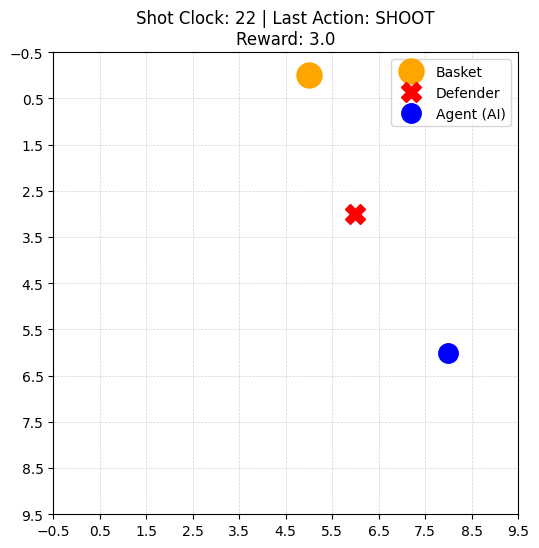

Game Simulation Finished!


In [47]:
import time
from stable_baselines3 import PPO

# Load your model and reset environment
model = PPO.load("ppo_basketball_agent_moving_defender_UI_V2")
env = Basketball2DEnv()
obs, info = env.reset()
done = False

action_names = {0: "Move Up", 1: "Move Down", 2: "Move Left", 3: "Move Right", 4: "SHOOT"}
reward = 0.0

# Render the starting frame
env.render(action_taken="Game Start", current_reward=reward)
time.sleep(1.0)

while not done:
    # Predict the action
    action, _states = model.predict(obs, deterministic=True)
    action_str = action_names[int(action)]
    
    # Process environment
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    
    # Render updated state
    env.render(action_taken=action_str, current_reward=reward)
    time.sleep(0.6) # Controls how fast the animation runs

print("Game Simulation Finished!")

In [60]:
# Load the trained model
model = PPO.load("ppo_basketball_agent_moving_defender_UI_V2")

# Test loop
obs, info = env.reset()
done = False
step_count = 0

print(f"\n--- Testing Trained Agent ---")
print(f"Starting Position: [{obs[0]}, {obs[1]}]")

while not done:
    # Predict the best action using the neural network
    action, _states = model.predict(obs, deterministic=True)
    
    # Map integers to strings for printing
    action_names = {0: "Move Up", 1: "Move Down", 2: "Move Left", 3: "Move Right", 4: "SHOOT"}
    print(f"Step {step_count}: Agent chose action -> {action_names[int(action)]}")
    
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    step_count += 1
    
    if not done:
        print(f"New Position: [{obs[0]}, {obs[1]}] | Shot Clock: {obs[4]}")
    else:
        print(f"Episode Ended. Final Reward: {reward}")


--- Testing Trained Agent ---
Starting Position: [7.0, 6.0]
Step 0: Agent chose action -> Move Up
New Position: [7.0, 5.0] | Shot Clock: 23.0
Step 1: Agent chose action -> SHOOT
Episode Ended. Final Reward: 3.0
